In [3]:
from langchain_core.messages import HumanMessage


In [5]:
HumanMessage("hi").json()

/var/folders/sg/g37t4f7913lcjhxywpvvlj700000gn/T/ipykernel_11937/4226728103.py:1: PydanticDeprecatedSince20: The `json` method is deprecated; use `model_dump_json` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.13/migration/
  HumanMessage("hi").json()


'{"content":"hi","additional_kwargs":{},"response_metadata":{},"type":"human","name":null,"id":null}'

In [41]:
from langgraph.graph import StateGraph,START,END,add_messages
from langchain_core.messages import BaseMessage,HumanMessage,AIMessage,SystemMessage,AIMessageChunk
from langgraph.types import interrupt,Command
from langgraph.checkpoint.memory import InMemorySaver
from dataclasses import dataclass, field 
from typing_extensions import Annotated ,Optional,List,Dict
from langchain_openai import ChatOpenAI
from uuid import uuid4

llm = ChatOpenAI(model="Qwen2.5-3B-Instruct-Q4_K_M.gguf",api_key="not require",temperature=0,base_url="http://localhost:8080")

@dataclass 
class State:
    messages :Annotated[List[BaseMessage],add_messages]


def node(state:State)->State:
    full_chunk = AIMessageChunk("")

    for chunk in llm.stream(state.messages):
        # print(chunk)
        full_chunk+=chunk

    ai_msg = AIMessage(content=full_chunk.content,id=str(uuid4()))

    user_input = interrupt("enter your name")
    print(user_input)

    return {"messages":[ai_msg]}

graph =(StateGraph(state_schema=State)
        .add_node('node',node)
        .add_edge(START,'node')
        .add_edge('node',END)
        .compile(checkpointer=InMemorySaver())
        )



In [49]:
config = {"configurable":{"thread_id":'55'}}
for chunk in graph.stream({'messages':[]},config=config,stream_mode=['values']):
    print(chunk)
# for chunk in graph.stream(input=Command(resume="chetan"),config=config,stream_mode=['values']):
    # print(chunk)



('values', {'messages': [AIMessage(content="Hello! I'm Qwen, an AI assistant created by Alibaba Cloud. How can I assist you today? Whether you need help with a specific topic, have a question, or just want to chat, I'm here to help to the best of my abilities.", additional_kwargs={}, response_metadata={}, id='c26a69c2-ce10-40f9-941e-20e1effc46e4', tool_calls=[], invalid_tool_calls=[])]})
('values', {'messages': [AIMessage(content="Hello! I'm Qwen, an AI assistant created by Alibaba Cloud. How can I assist you today? Whether you need help with a specific topic, have a question, or just want to chat, I'm here to help to the best of my abilities.", additional_kwargs={}, response_metadata={}, id='c26a69c2-ce10-40f9-941e-20e1effc46e4', tool_calls=[], invalid_tool_calls=[])], '__interrupt__': (Interrupt(value='enter your name', id='5f0063633894833a701040f1c2966727'),)})


In [50]:
graph.get_state(config=config).interrupts
# graph.get_state(config=config).values #value

(Interrupt(value='enter your name', id='5f0063633894833a701040f1c2966727'),)

In [53]:
from piper import PiperVoice
from sounddevice import a
voice = PiperVoice.load("en_US-lessac-medium.onnx")
voice.synthesize("hello")

<generator object PiperVoice.synthesize at 0x11cb34700>

TypeError: PiperVoice.__init__() missing 1 required positional argument: 'config'

In [46]:

# silence=1
# audio_buffer=[]
# start_buffer=False
# start_silence=None
# if vad(track):
#     start_buffer=True
#     start_silence = None
#     audio_buffer.append(track)
# else:
#     if start_buffer :
#         if start_silence is None:
#             start_silence=time.time()
#         audio_buffer.append(track)
#         if time.time()-start_silence >silence:
#             start_buffer=False
#             start_silence = None
#             asyncio.create_task(agent_run(audio_buffer))
#             audio_buffer=[]


In [ ]:
from langgraph.graph import START,END,StateGraph,add_messages
from langchain_core.messages import BaseMessage,SystemMessage,AIMessageChunk ,AIMessage,HumanMessage,RemoveMessage
from dataclasses import dataclass ,field
from langchain_openai import ChatOpenAI
from langgraph.config import get_stream_writer
from langgraph.types import Command,Send,interrupt
from langchain_core.runnables import RunnableConfig
from langgraph.runtime import Runtime
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.store.memory import InMemoryStore
from langchain_core.prompts import ChatPromptTemplate,MessagesPlaceholder
from typing_extensions import Annotated,List,Literal,Callable,Optional,TypedDict
from datetime import datetime
from langgraph.prebuilt import ToolNode
from langchain.tools import tool


@tool
def datetime_tool():
    """for access current date and time"""
    return datetime.now().strftime("%d/%m/%Y, %H:%M:%S")
tools =[datetime_tool]
llm = ChatOpenAI(model="Qwen2.5-3B-Instruct-Q4_K_M.gguf",api_key="not_need",base_url="http://localhost:8080")
llm_tools = llm.bind_tools(tools=tools)


class Context(TypedDict):
    # func:callable|type|None = None
    func:Optional[Callable|type] =None

@dataclass
class State:
    messages:Annotated[List[BaseMessage|str],add_messages] =field(default_factory=list)

tool_node = ToolNode(tools=tools)

def should_continue(state:State)->Literal["end","tool_node"]:
    if not state.messages:
        return "end"
    last_message =state.messages[-1]
    if isinstance(last_message,AIMessage) and last_message.tool_calls:
        return "tool_node"
    else:
        return "end"

async def node(state:State,config:RunnableConfig ,runtime:Runtime[Context]):
    func = runtime.context['func']
    store = runtime.store
    user_id = config.get("configurable",None).get("user_id",None)
    if user_id:
        history_messages= store.get(("user",user_id),"messages",None)
    if func:
        result = func()
        print("func",result)

    writer =get_stream_writer()
    prompt =ChatPromptTemplate.from_messages([SystemMessage("""You are a friendly, natural, and helpful voice AI assistant.

Your goal is to have smooth, human-like conversations.

Voice conversation rules:
- Keep responses concise and easy to understand when spoken aloud.
- Use natural conversational language rather than formal or robotic wording.
- Avoid unnecessary lists, tables, markdown, and long explanations.
- Ask one question at a time.
- Do not repeat information unnecessarily.
- If the user interrupts or changes the topic, adapt immediately.
- If you don't understand something, politely ask for clarification.
- Use short sentences and natural pauses.
- Do not describe your internal reasoning.
- Be helpful, friendly, and confident.
- Match the user's tone and level of formality.

When answering:
1. Understand what the user is asking.
2. Give the most useful answer directly.
3. If more information is needed, ask a concise follow-up question.

The conversation history is provided below."""),MessagesPlaceholder("history",optional=True),MessagesPlaceholder("messages")])
    
    chain = prompt | llm_tools

    full_chunk=None
    async for chunk in chain.astream({"messages":state.messages,"history":history_messages}):
        if full_chunk is None:
            full_chunk = chunk
        else:
            full_chunk +=chunk
        writer(AIMessage(full_chunk.content))

    return {"messages":[AIMessage(content=full_chunk.content,tool_calls=full_chunk.tool_calls)]}

graph = (StateGraph(state_schema=State)
        .add_node("node",node)
        .add_node("tool_node",tool_node)
        .add_edge(START,"node")
        .add_conditional_edges("node",should_continue,{"tool_node":"tool_node","end":END})
        .add_edge("tool_node","node")
        )

    




In [35]:
agent = graph.compile()

res =await agent.ainvoke({"messages":["hi"]},context={"func":lambda:"hello"})

func hello


In [ ]:
# agent = graph.compile(checkpointer=InMemorySaver(),store=InMemoryStore())

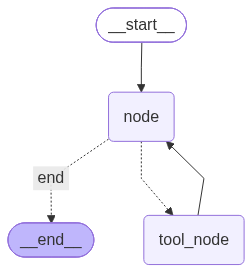

In [6]:
from IPython.display import Image
Image(agent.get_graph().draw_mermaid_png())

In [95]:
config={"configurable":{'thread_id':'55'}}
async for chunk in agent.astream({'messages':[HumanMessage('current time')]},config=config,stream_mode=['values',"custom"]):
    print(chunk)

('values', {'messages': [HumanMessage(content='muje google ke bare me btao', additional_kwargs={}, response_metadata={}, id='178bf446-0542-42c2-923b-5a8a5ef39031'), AIMessage(content="Sure, I can help with that. Could you please tell me what specific information you're looking for about you?", additional_kwargs={}, response_metadata={}, id='f0cacea4-b6e0-4403-96b0-7a957e8d522a', tool_calls=[], invalid_tool_calls=[]), HumanMessage(content='dattime current ', additional_kwargs={}, response_metadata={}, id='9decb5ca-76d4-4321-a3df-099b51920b6f'), AIMessage(content='', additional_kwargs={}, response_metadata={}, id='5f09d68d-6719-465c-acb3-df31a02f2d53', tool_calls=[{'name': 'datetime_tool', 'args': {}, 'id': 'lu5c1KBERVm4cLNnhUWLviMCdyYrPYWi', 'type': 'tool_call'}], invalid_tool_calls=[]), ToolMessage(content='02/09/2026, 18:00:20', name='datetime_tool', id='6130ee41-9955-496c-90ec-7f18b2602d45', tool_call_id='lu5c1KBERVm4cLNnhUWLviMCdyYrPYWi'), AIMessage(content='The current date and tim

In [74]:
import datetime
datetime.datetime.now().strftime("%d/%m/%Y, %H:%M:%S")

'02/09/2026, 17:39:14'

{'messages': [HumanMessage(content='hi', additional_kwargs={}, response_metadata={}, id='252546e8-3601-4c96-88de-6d861e2dea27'),
  AIMessage(content='Hello! How can I assist you today?', additional_kwargs={}, response_metadata={}, id='eac61abe-caf1-41b4-ab5a-a9ce50ed0db9', tool_calls=[], invalid_tool_calls=[])]}